# Benchmark of NTR

This notebook analysis the NTR of genes

In [1]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Benchmark of NTR (scatter)

In [2]:
data = dict()

# NASC-seq

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U0uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["GSE128273_NASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U50uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["GSE128273_NASCseq.K562.s4U50uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U0uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["NASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U50uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["NASCseq.K562.s4U50uM180min"] = d

(5321, 20)
(5116, 20)
(5731, 20)
(5060, 20)


In [4]:
# NanoNASC-seq

d = pd.read_csv("../05_expression/results/pseudobulk/expression.K562.s4U0uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 50)]
print(d.shape)
data["NanoNASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.K562.s4U50uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 50)]
print(d.shape)
data["NanoNASCseq.K562.s4U50uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.mESC.s4U0uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 50)]
print(d.shape)
data["NanoNASCseq.mESC.s4U0uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.mESC.s4U400uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 50)]
print(d.shape)
data["NanoNASCseq.mESC.s4U400uM180min"] = d

(5035, 16)
(2429, 16)
(2285, 16)
(2405, 16)


In [5]:
for k, v in data.items():
    print(v.shape, k, sep="\t")

(5321, 20)	GSE128273_NASCseq.K562.s4U0uM180min
(5116, 20)	GSE128273_NASCseq.K562.s4U50uM180min
(5731, 20)	NASCseq.K562.s4U0uM180min
(5060, 20)	NASCseq.K562.s4U50uM180min
(5035, 16)	NanoNASCseq.K562.s4U0uM180min
(2429, 16)	NanoNASCseq.K562.s4U50uM180min
(2285, 16)	NanoNASCseq.mESC.s4U0uM180min
(2405, 16)	NanoNASCseq.mESC.s4U400uM180min


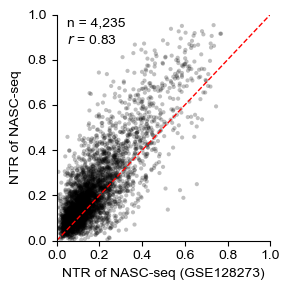

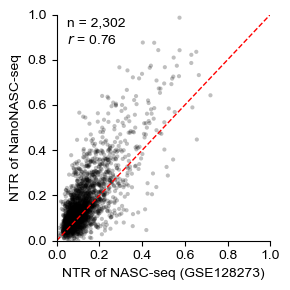

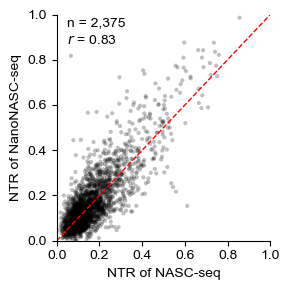

In [7]:
def plot_ntr_correlation(data, name1, name2, xlabel, ylabel):
    s1 = data[name1]["NTR"]
    s1.name = name1
    s2 = data[name2]["NTR"]
    s2.name = name2
    m = pd.concat([s1, s2], axis=1, join="inner")
    
    xs = m[name1]
    ys = m[name2]
    r = pearsonr(xs, ys)[0]
    # print(r)
    
    plt.figure(figsize=(3, 3))
    # sns.kdeplot(m, x="GSE128273_NASCseq", y="NASCseq", fill=True)
    plt.scatter(xs, ys, marker=".", color="black", edgecolor="none", alpha=0.25)
    plt.plot([0, 1], [0, 1], lw=1, ls="--", color="red")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.text(0.05, 0.87, "$\it{r}$ = %.2f" % r)
    plt.text(0.05, 0.95, "n = %s" % format(len(xs), ","))

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/correlation_of_ntr.scatter.%s_vs_%s.pdf" % (name1, name2))
    plt.show()
    plt.close()
plot_ntr_correlation(data, "GSE128273_NASCseq.K562.s4U50uM180min", "NASCseq.K562.s4U50uM180min", "NTR of NASC-seq (GSE128273)", "NTR of NASC-seq")
plot_ntr_correlation(data, "GSE128273_NASCseq.K562.s4U50uM180min", "NanoNASCseq.K562.s4U50uM180min", "NTR of NASC-seq (GSE128273)", "NTR of NanoNASC-seq")
plot_ntr_correlation(data, "NASCseq.K562.s4U50uM180min", "NanoNASCseq.K562.s4U50uM180min", "NTR of NASC-seq", "NTR of NanoNASC-seq")

## 2. NTR of example genes (barplot)

    MYC, PDLIM5, GAPDH

In [8]:
data = dict()

# NASC-seq

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U0uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["GSE128273_NASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U50uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["GSE128273_NASCseq.K562.s4U50uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U0uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["NASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U50uM180min.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["Count"] >= 100) & (d["FPKM"] >= 5)]
d.index = d["GeneID"]
print(d.shape)
data["NASCseq.K562.s4U50uM180min"] = d

# NanoNASC-seq

d = pd.read_csv("../05_expression/results/pseudobulk/expression.K562.s4U0uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 0)]
print(d.shape)
data["NanoNASCseq.K562.s4U0uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.K562.s4U50uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 0)]
print(d.shape)
data["NanoNASCseq.K562.s4U50uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.mESC.s4U0uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 0)]
print(d.shape)
data["NanoNASCseq.mESC.s4U0uM180min"] = d

d = pd.read_csv("../05_expression/results/pseudobulk/expression.mESC.s4U400uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 0)]
print(d.shape)
data["NanoNASCseq.mESC.s4U400uM180min"] = d

(5321, 20)
(5116, 20)
(5731, 20)
(5060, 20)
(11767, 16)
(10766, 16)
(11645, 16)
(11727, 16)


GSE128273_NASCseq
NASCseq
NanoNASCseq


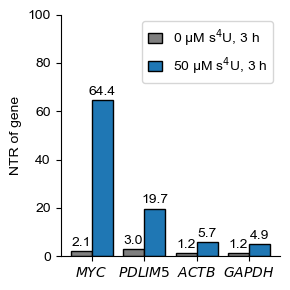

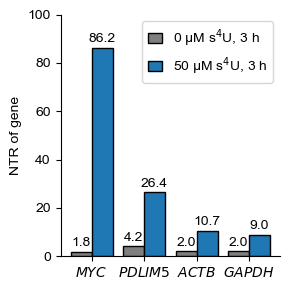

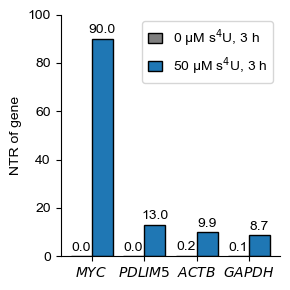

In [40]:
gnames = ["MYC", "PDLIM5", "ACTB", "GAPDH"]
for name in ["GSE128273_NASCseq", "NASCseq", "NanoNASCseq"]:
    print(name)
    name1 = "%s.K562.s4U0uM180min" % name
    name2 = "%s.K562.s4U50uM180min" % name
    
    d1 = data[name1]
    d2 = data[name2]
    #tids = [p[0] for p in params]
    #gnames = [p[1] for p in params]
    gids = []
    for g in gnames:
        gids.append(d1[d1["GeneName"] == g].index.values[0])
    ys1 = d1.loc[gids]["NTR"] * 100
    ys2 = d2.loc[gids]["NTR"] * 100
    xs = np.arange(len(gids))
    colors = ["C7", "C0"]
    w = 0.4
    labels = ["0 μM s$^4$U, 3 h", "50 μM s$^4$U, 3 h"]
    
    plt.figure(figsize=(3, 3))
    for i, ys in enumerate([ys1, ys2]):
        xs1 = xs + (i-0.5)*w
        plt.bar(xs1, ys, color=colors[i], width=w, edgecolor="black", label=labels[i])
        for x, y in zip(xs1, ys):
            plt.text(x, y + 1, "%.1f" % y, ha="center", va="bottom")
    plt.xticks(xs, ["$\it{%s}$" % g for g in gnames])
    plt.ylabel("NTR of gene")
    plt.ylim(0, 100)
    plt.legend(handlelength=1)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/ntr_of_star_genes.%s.pdf" % name)

(2429, 16)


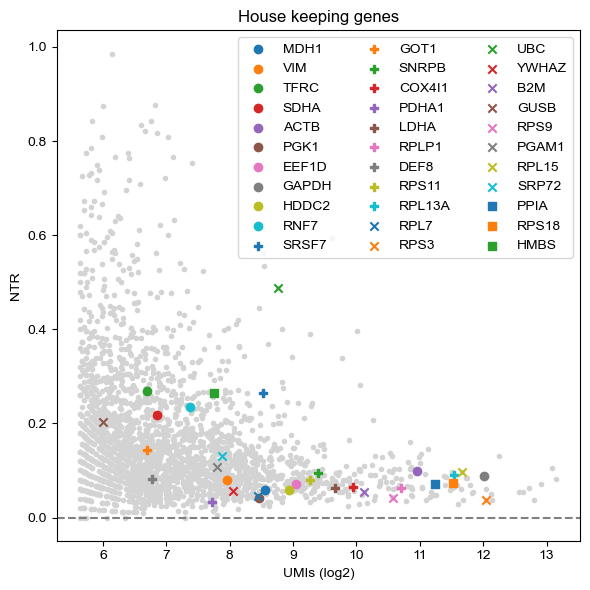

In [45]:
# Find long half-life genes

d = pd.read_csv("../05_expression/results/pseudobulk/expression.K562.s4U50uM180min.2TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 50)]
print(d.shape)


a = pd.read_excel("../../02_cell_line/02_halflife_of_gene/data/mouse_house_keeping_genes_70.xlsx")
genes = [g.upper() for g in a["Symbol"]]
# genes = ["ACTB", "GAPDH"]

xs = np.log2(d["Total"])
ys = d["NTR"]
d1 = d[d["GeneName"].isin(genes)]
xs1, ys1 = np.log2(d1["Total"]), d1["NTR"]
plt.figure(figsize=(6, 6))
plt.title("House keeping genes")
plt.scatter(xs, ys, marker=".", color="lightgrey")
# plt.scatter(xs1, ys1, marker="o", color="C3")
markers = ["o", "P", "x", "s", "k"]
for i, (x, y, gname) in enumerate(zip(np.log2(d1["Total"]), d1["NTR"], d1["GeneName"])):
    plt.scatter(x, y, label=gname, color="C%d" % (int(i%10)), marker=markers[int(i/10)])
plt.axhline(0, ls="--", color="grey")
plt.ylabel("NTR")
plt.xlabel("UMIs (log2)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

## 3. Make bam for IGV

In [91]:
d = pd.read_excel("../../1_NanoNASCseq/data/NanoNASCseq_summary_selected.xls")
df = d[(d["Strain"] == "K562") & (d["ActD"].isna()) & (d["Time"] == 3) & (d["UMIs"] >= 5000)]
df1 = df[(df["s4U"] == 0)]
df2 = df[(df["s4U"] == 50) & (df["TCRatio"] >= 0.00) & (df["TCRatio"] < 0.02)]
print(len(df1), len(df2))

190 173


In [110]:
import pysam
import subprocess

locs = [
    ["chr8", 127735000, 127744000, "MYC"],
    ["chr1", 28735000, 28770000, "YTHDF2"]
]

for loc in locs:
    fw = None
    bamfile = "results/K562_%s.0uM3h.bam" % loc[3]
    bamfile2 = "results/K562_%s.0uM3h.sorted.bam" % loc[3]
    for run, cell in df1[["Run", "Cell"]].values:
        path = "../../1_NanoNASCseq/results/mismatch/events/%s/%s.bam" % (run, cell)
        with pysam.AlignmentFile(path) as f:
            if fw is None:
                fw = pysam.AlignmentFile(bamfile, "wb", f)
            segments = defaultdict(list)
            for s in f.fetch(loc[0], loc[1], loc[2]):
                segments[s.get_tag("CN")].append(s)
            for k, v in segments.items():
                if len(v) > 1:
                    v = v[:min(len(v), 3)]
                    for s in v:
                        fw.write(s)     
    subprocess.check_call("samtools sort -o %s %s" % (bamfile2, bamfile), shell=True)
    subprocess.check_call("samtools index %s" % bamfile2, shell=True)

    fw = None
    bamfile = "results/K562_%s.50uM3h.bam" % loc[3]
    bamfile2 = "results/K562_%s.50uM3h.sorted.bam" % loc[3]
    for run, cell in df2[["Run", "Cell"]].values:
        path = "../../1_NanoNASCseq/results/mismatch/events/%s/%s.bam" % (run, cell)
        with pysam.AlignmentFile(path) as f:
            if fw is None:
                fw = pysam.AlignmentFile(bamfile, "wb", f)
            segments = defaultdict(list)
            for s in f.fetch(loc[0], loc[1], loc[2]):
                segments[s.get_tag("CN")].append(s)
            for k, v in segments.items():
                if len(v) > 1:
                    v = v[:min(len(v), 3)]
                    for s in v:
                        fw.write(s)       
    subprocess.check_call("samtools sort -o %s %s" % (bamfile2, bamfile), shell=True)
    subprocess.check_call("samtools index %s" % bamfile2, shell=True)

0